In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [15]:
from pathlib import Path
from itertools import cycle
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from tqdm.notebook import tqdm

In [3]:
from magneton.config import PipelineConfig
from magneton.data import (
    MagnetonDataModule,
    SupervisedDownstreamTaskDataModule,
)
from magneton.data.core import Batch, get_substructure_parser
from magneton.data.evaluations import (
    EVAL_TASK,
    TASK_TO_TYPE,
)
from magneton.models.substructure_classifier import SubstructureClassifier
from magneton.models.evaluation_classifier import (
    _create_head_module,
    _get_labels_for_loss,
)
from magneton.models.utils import parse_hidden_dims

In [16]:
grads_path = Path("/home/rcalef/storage/om_storage/projects/magneton/experiments/gradient_conflicts/")
tasks = [
    "GO:MF",
    "EC",
    "FLIP_bind",
    "biolip_binding",
    "biolip_catalytic",
]

def sims_to_df(task):
    path = grads_path / f"{task}.esm2_150m.grad_sims.pt"
    sims = torch.load(path)
    all_sims = []
    for key, vals in sims.items():
        all_sims.append(pd.DataFrame({
            "sim": vals,
            "comparison": key,
        }))
    return pd.concat(all_sims).assign(task=task)

data = []
for task in tasks:
    data.append(sims_to_df(task))
data = pd.concat(data)
data.task.value_counts()

task
GO:MF               766
EC                  766
FLIP_bind           766
biolip_binding      766
biolip_catalytic    766
Name: count, dtype: int64

In [17]:
data.head()

,sim,comparison,task
0,-0.071691,cross_sims,GO:MF
1,-0.007036,cross_sims,GO:MF
2,-0.022677,cross_sims,GO:MF
3,-0.068700,cross_sims,GO:MF
4,-0.021143,cross_sims,GO:MF


In [20]:
data.query("task == 'GO:MF'").head()

,sim,comparison,task
0,-0.071691,cross_sims,GO:MF
1,-0.007036,cross_sims,GO:MF
2,-0.022677,cross_sims,GO:MF
3,-0.068700,cross_sims,GO:MF
4,-0.021143,cross_sims,GO:MF


In [23]:
(
    data
    .query("comparison == 'cross_sims'")
    .groupby("task")
    .sim
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
task,,,,,,,,
EC,256.0,0.003220,0.026699,-0.068037,-0.013746,0.005448,0.022304,0.081028
FLIP_bind,256.0,0.021949,0.055555,-0.134454,-0.014756,0.023564,0.063196,0.154830
GO:MF,256.0,-0.006203,0.046612,-0.117558,-0.034460,-0.007103,0.025401,0.106731
biolip_binding,256.0,0.002251,0.055122,-0.124750,-0.035563,-0.000316,0.040848,0.136651
biolip_catalytic,256.0,-0.004922,0.038493,-0.097134,-0.032941,-0.006766,0.017383,0.113773


In [25]:
(
    data
    .query("comparison == 'self_substruct_sims'")
    .groupby("task")
    .sim
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
task,,,,,,,,
EC,255.0,0.088000,0.073956,-0.111627,0.040266,0.087731,0.132693,0.324713
FLIP_bind,255.0,0.092291,0.082371,-0.087372,0.034721,0.075282,0.136031,0.340111
GO:MF,255.0,0.096512,0.084945,-0.155139,0.039441,0.090335,0.157226,0.366656
biolip_binding,255.0,0.094588,0.067153,-0.080478,0.045067,0.095319,0.141393,0.274575
biolip_catalytic,255.0,0.105192,0.076063,-0.120834,0.053178,0.105908,0.153873,0.318767


In [27]:
(
    data
    .query("comparison == 'self_substruct_sims'")
    .sim
    .describe()
)

count    1275.000000
mean        0.095317
std         0.077245
min        -0.155139
25%         0.041785
50%         0.090815
75%         0.145201
max         0.366656
Name: sim, dtype: float64

In [26]:
(
    data
    .query("comparison == 'self_eval_sims'")
    .groupby("task")
    .sim
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
task,,,,,,,,
EC,255.0,0.956450,0.004305,0.932055,0.954728,0.957095,0.959112,0.964355
FLIP_bind,255.0,0.961657,0.005483,0.944353,0.958648,0.961871,0.965711,0.969530
GO:MF,255.0,0.956547,0.004462,0.941357,0.953618,0.957070,0.959875,0.965237
biolip_binding,255.0,0.963781,0.007451,0.927078,0.961758,0.965731,0.968384,0.974619
biolip_catalytic,255.0,0.973456,0.021811,0.825599,0.975665,0.978228,0.979979,0.984226


<Axes: xlabel='sim', ylabel='Count'>

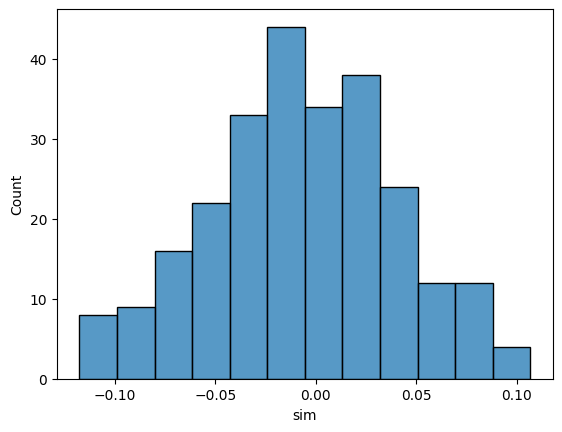

In [24]:
plot_data = (
    data
    .query("comparison == 'cross_sims' and task == 'GO:MF'")
)

sns.histplot(x="sim", data=plot_data)

<Axes: xlabel='task', ylabel='sim'>

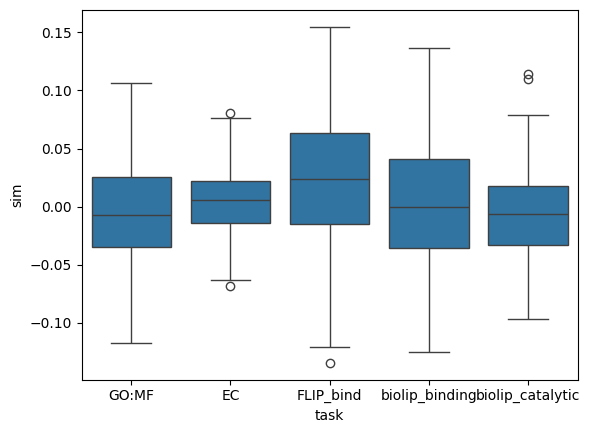

In [22]:
plot_data = (
    data
    .query("comparison == 'cross_sims'")
)

sns.boxplot(x="task", y="sim", data=plot_data)

In [5]:
sims_path = "/weka/scratch/weka/kellislab/rcalef/projects/magneton/experiments/gradient_conflicts/go_mf.grad_sims.pt"
sims = torch.load(sims_path)

In [10]:
sims_df = sims_to_df(sims_path)
sims_df.comparison.value_counts()

comparison
cross_sims             1000
self_substruct_sims     999
self_eval_sims          999
Name: count, dtype: int64

In [14]:
sims_df.groupby("comparison").sim.describe()

,count,mean,std,min,25%,50%,75%,max
comparison,,,,,,,,
cross_sims,1000.0,-0.057955,0.216042,-0.534036,-0.239326,-0.053090,0.112321,0.446990
self_eval_sims,999.0,0.981325,0.011193,0.895771,0.977587,0.985039,0.988509,0.993000
self_substruct_sims,999.0,0.073089,0.230974,-0.625030,-0.069366,0.065639,0.211596,0.693694


<Axes: xlabel='sim', ylabel='Count'>

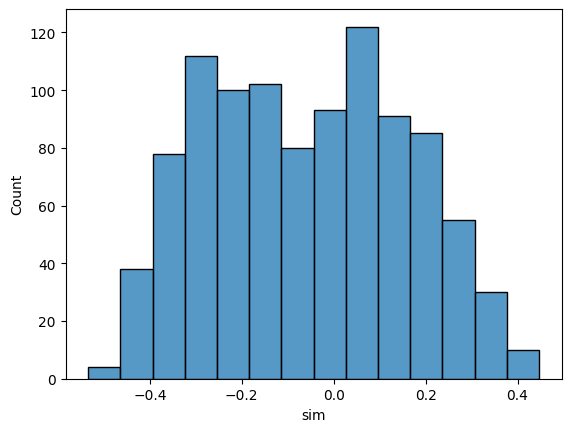

In [12]:
sns.histplot(sims_df.query("comparison == 'cross_sims'").sim)

<Axes: xlabel='sim', ylabel='Count'>

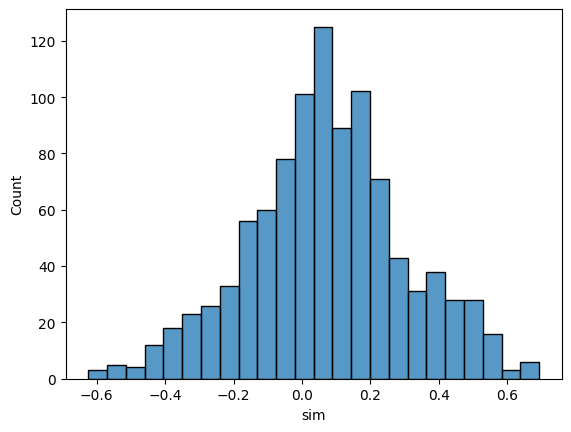

In [13]:
sns.histplot(sims_df.query("comparison == 'self_substruct_sims'").sim)

In [4]:
num_workers = 16
device = "cuda" if torch.cuda.is_available() else "cpu"

In an attempt to understand why substructure-tuning consistently improves performance on some benchmarks (e.g. GO:MF, EC) and hurts performance on others (e.g. residue-level functional site classification), we'll perform a gradient conflict analysis.

The steps in this analysis are:
- Set up dataloader for Magneton substructure dataset (train set)
- For a given benchmark, set up dataloader for train set
- Initialize a base model (e.g. ESM-C 300M)
- Construct a substructure classifier head on top of the base model
- Construct a evaluation classifier head on top of the base model
- For N iterations
    - Sample batch from substructure set, calculate substructure loss, backprop, get base model gradients
    - Same as above for evaluation batch
    - Normalize and calculate cosine sim between gradient vectors
    

## Prepare datasets

In [5]:
config_dir = "/home/rcalef/sandbox/repos/magneton/magneton/configs"
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(
        config_name="config",
        overrides=[
            "base_model='esmc_300m'",
            "+evaluate=deepfri",
            "output_dir='/tmp/'",
            "evaluate.model_checkpoint='/tmp'",
            "data='debug'",
            "data.struct_template='/weka/scratch/weka/kellislab/rcalef/data/pdb_alphafolddb/AF-%s-F1-model_v4.pdb'",
        ],
    )
config = instantiate(cfg)
config

PipelineConfig(_target_='magneton.config.PipelineConfig', seed=42, stage='train', output_dir='/tmp/', run_id='my_new_run', data=DataConfig(_target_='magneton.config.DataConfig', data_dir='/weka/scratch/weka/kellislab/rcalef/data/magneton-data/interpro_103.0/debug_subset', compression='gz', prefix='swissprot.with_ss', splits='/weka/scratch/weka/kellislab/rcalef/data/magneton-data/interpro_103.0/dataset_splits/seq_splits.tsv', batch_size=32, fasta_path='/weka/scratch/weka/kellislab/rcalef/data/magneton-data/sequences/uniprot_sprot.fasta.gz', labels_path='/weka/scratch/weka/kellislab/rcalef/data/magneton-data/interpro_103.0/labels/selected_subset', struct_template='/weka/scratch/weka/kellislab/rcalef/data/pdb_alphafolddb/AF-%s-F1-model_v4.pdb', substruct_types=['Domain'], collapse_labels=False, num_loader_workers=32, model_specific_params={}), base_model=BaseModelConfig(_target_='magneton.config.BaseModelConfig', model='esmc', model_params={'model_size': '300m', 'weights_path': '/weka/scr

In [6]:
def prep_data_modules(
    config: PipelineConfig,
    eval_task: str,
    num_workers: int = 16,
) -> tuple[torch.utils.data.DataLoader]:
    model_type = config.base_model.model
    magneton_module = MagnetonDataModule(
        data_config=config.data,
        model_type=model_type,
        num_workers=num_workers,
    )

    eval_module = SupervisedDownstreamTaskDataModule(
        data_config=config.data,
        task=eval_task,
        data_dir=config.evaluate.data_dir,
        model_type=model_type,
        unk_amino_acid_char=config.base_model.model_params.get(
            "unk_amino_acid_char", "X"
        ),
        num_workers=num_workers,
    )
    return magneton_module, eval_module

## Set up model

In [7]:
def prep_models(
    config: PipelineConfig,
    eval_task: str,
    eval_module: SupervisedDownstreamTaskDataModule,
) -> dict[Any]:
    substruct_parser = get_substructure_parser(config.data)
    model = SubstructureClassifier(
        config=config,
        num_classes=substruct_parser.num_labels(),
    )
    model.base_model._unfreeze()

    task_type = TASK_TO_TYPE[eval_task]
    task_granularity = eval_module.task_granularity
    embed_dim = model.base_model.get_embed_dim()
    hidden_dims = parse_hidden_dims(
        raw_dims=config.model.model_params["hidden_dims"], embed_dim=embed_dim
    )
    num_classes = eval_module.num_classes()

    eval_head = _create_head_module(
        task_granularity=task_granularity,
        embed_dim=embed_dim,
        hidden_dims=hidden_dims,
        num_classes=num_classes,
        dropout_rate=config.model.model_params["dropout_rate"],
    )

    if task_type == EVAL_TASK.MULTILABEL:
        eval_loss = nn.BCEWithLogitsLoss()
    elif task_type == EVAL_TASK.MULTICLASS:
        eval_loss = nn.CrossEntropyLoss()
    elif task_type == EVAL_TASK.BINARY:
        eval_loss = nn.BCEWithLogitsLoss()
    elif task_type == EVAL_TASK.REGRESSION:
        eval_loss = nn.MSELoss()

    return {
        "substruct_model": model,
        "head_model": eval_head,
        "task_type": task_type,
        "eval_loss": eval_loss,
    }

In [8]:
def _extract_base_grads(
    model: SubstructureClassifier,
) -> torch.Tensor:
    all_grads = []
    for params in model.base_model.parameters():
        if params.requires_grad and params.grad is not None:
            all_grads.append(torch.flatten(params.grad.detach()))
    all_grads = torch.cat(all_grads)
    all_grads = all_grads / torch.norm(all_grads)

    model.zero_grad()
    return all_grads


def get_substruct_grads(
    model: SubstructureClassifier,
    batch: Batch,
) -> torch.Tensor:
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        substruct_loss = model.training_step(batch, 0)
    substruct_loss.backward()

    return _extract_base_grads(model)

def get_eval_grads(
    model: SubstructureClassifier,
    head_model: nn.Module,
    batch: Batch,
    loss_fn: nn.Module,
    task_type: EVAL_TASK,
) -> torch.Tensor:
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        logits = head_model.forward(batch, model.base_model)
        labels = head_model.process_labels(batch, logits)
        labels = _get_labels_for_loss(labels, task_type, logits.dtype)
        loss = loss_fn(logits, labels)
    loss.backward()

    return _extract_base_grads(model)


In [9]:
def run_one_analysis(
    config: PipelineConfig,
    eval_task: str,
    tot_iters: int,
    num_workers: int = 16,
) -> list[float]:
    magneton_module, eval_module = prep_data_modules(
        config=config,
        eval_task=eval_task,
        num_workers=num_workers,
    )

    magneton_loader = magneton_module.train_dataloader()
    eval_loader = eval_module.train_dataloader()

    model_parts = prep_models(
        config,
        eval_task=eval_task,
        eval_module=eval_module,
    )

    substruct_model = model_parts["substruct_model"]
    head_model = model_parts["head_model"]
    eval_task_type = model_parts["task_type"]
    eval_loss_fn = model_parts["eval_loss"]

    substruct_model = substruct_model.to(device)
    head_model = head_model.to(device)

    magneton_iter = cycle(magneton_loader)
    eval_iter = cycle(eval_loader)

    cross_sims = []
    self_substruct_sims = []
    self_eval_sims = []

    prev_substruct_grad = None
    prev_eval_grad = None

    num_iters = 0
    for _ in tqdm(range(tot_iters)):
        substruct_batch = next(magneton_iter)
        eval_batch = next(eval_iter)
        substruct_batch = substruct_batch.to(device)
        eval_batch = eval_batch.to(device)

        substruct_grads = get_substruct_grads(substruct_model, substruct_batch)
        eval_grads = get_eval_grads(
            substruct_model,
            head_model=head_model,
            batch=eval_batch,
            loss_fn=eval_loss_fn,
            task_type=eval_task_type,
        )

        sim = eval_grads @ substruct_grads
        cross_sims.append(sim.item())
        if prev_substruct_grad is not None:
            sim = substruct_grads @ prev_substruct_grad
            self_substruct_sims.append(sim.item())
        if prev_eval_grad is not None:
            sim = eval_grads @ prev_eval_grad
            self_eval_sims.append(sim.item())
        prev_substruct_grad = substruct_grads
        prev_eval_grad = eval_grads

        num_iters += 1

    return cross_sims, self_substruct_sims, self_eval_sims

In [10]:
cross_sims, self_substruct_sims, self_eval_sims = run_one_analysis(
    config=config,
    eval_task="GO:MF",
    tot_iters=10,
)
print(cross_sims[:5])
print(self_substruct_sims[:5])
print(self_eval_sims[:5])

Forcing collapse_labels to True for simplicity.


processing proteins: 100%|████████████████████████████████| 1/1 [00:07<00:00,  7.42s/it]
INFO:magneton.data.core.unified_dataset:split train: got 2846 proteins
INFO:magneton.data.data_modules:remaining proteins after length filter: 2793 / 2846
INFO:magneton.data.evaluations.deepfri_dataset:found PDB-UniProt mapping at: /weka/scratch/weka/kellislab/rcalef/data/magneton-data/evaluations/GeneOntology/MF.pdb_to_uniprot.tsv
INFO:magneton.data.evaluations.deepfri_dataset:downloading 1557 / 30069 missing files
100%|███████████████████████████████████████████████| 1557/1557 [00:17<00:00, 86.58it/s]
INFO:magneton.data.evaluations.utils:succesfully downloaded 0  / 1557 files
INFO:magneton.data.evaluations.utils:FASTA cache found at /weka/scratch/weka/kellislab/rcalef/data/magneton-data/evaluations/GeneOntology/MF.seqs_from_pdbs.fa
INFO:magneton.data.data_modules:remaining proteins after length filter: 22479 / 22621
INFO:magneton.models.substructure_classifier:head model: ModuleDict(
  (default):

  0%|          | 0/10 [00:00<?, ?it/s]

[-0.13078796863555908, 0.605976402759552, 0.21277321875095367, 0.7004656791687012, 0.5113927125930786]
[-0.09374673664569855, 0.27622854709625244, 0.20205192267894745, 0.45056983828544617, 0.11404536664485931]
[0.9958151578903198, 0.9958398342132568, 0.9953335523605347, 0.9947342872619629, 0.993904709815979]


In [1]:
print("test")

test


In [2]:
import numpy as np

In [4]:
test = np.random.rand(10)
test.shape

(10,)

In [5]:
test @ test

3.305275427612662